## **Loss Function with Interactive Slider**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact

def f(x, a, b, c):
    return a*x**2 + b*x + c

def plot_interactive(a=1, b=0, c=0):
    x = np.linspace(-10, 10, 400)
    y = f(x, a, b, c)

    # Minimum analytically
    x_min = -b / (2*a) if a != 0 else 0
    y_min = f(x_min, a, b, c)

    plt.figure()
    plt.plot(x, y, label="f(x)")
    plt.scatter(x_min, y_min)
    plt.text(x_min, y_min, f"Min ({x_min:.2f}, {y_min:.2f})")

    plt.title("Interactive Quadratic Function")
    plt.grid()
    plt.legend()
    plt.show()

interact(plot_interactive, a=(-5,5,0.5), b=(-10,10,1), c=(-10,10,1))

interactive(children=(FloatSlider(value=1.0, description='a', max=5.0, min=-5.0, step=0.5), IntSlider(value=0,…

<function __main__.plot_interactive(a=1, b=0, c=0)>

## **Gradient Descent Animation**

/usr/local/lib/python3.12/dist-packages/matplotlib/animation.py:908: UserWarning:

Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.



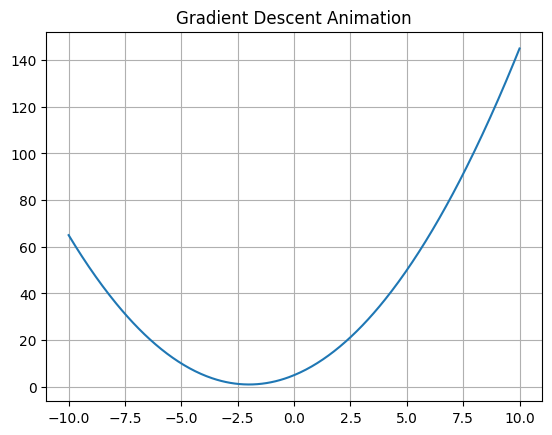

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

def f(x):
    return x**2 + 4*x + 5

def grad(x):
    return 2*x + 4

def gradient_descent(x0, lr=0.1, steps=20):
    x_vals = [x0]
    x = x0

    for _ in range(steps):
        x = x - lr * grad(x)
        x_vals.append(x)

    return x_vals

x_vals = gradient_descent(x0=8)

x = np.linspace(-10, 10, 400)
y = f(x)

fig, ax = plt.subplots()
ax.plot(x, y)

point, = ax.plot([], [], 'ro')

def update(frame):
    x_current = x_vals[frame]
    y_current = f(x_current)
    point.set_data([x_current], [y_current])
    return point,

ani = FuncAnimation(fig, update, frames=len(x_vals), interval=500)
plt.title("Gradient Descent Animation")
plt.grid()
plt.show()

## **3D Surface Plot (Multivariable Function)**


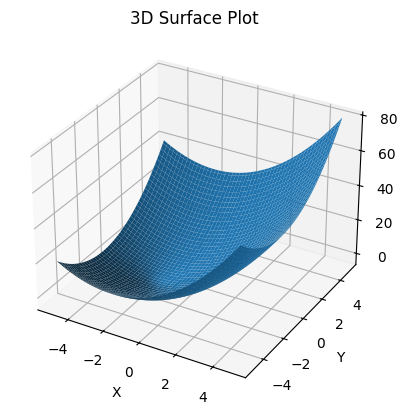

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def f(x, y):
    return x**2 + y**2 + 4*x + 2*y

x = np.linspace(-5, 5, 100)
y = np.linspace(-5, 5, 100)

X, Y = np.meshgrid(x, y)
Z = f(X, Y)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(X, Y, Z)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('f(X,Y)')
ax.set_title("3D Surface Plot")

plt.show()

## **Gradient Descent in 3D (Path Visualization)**

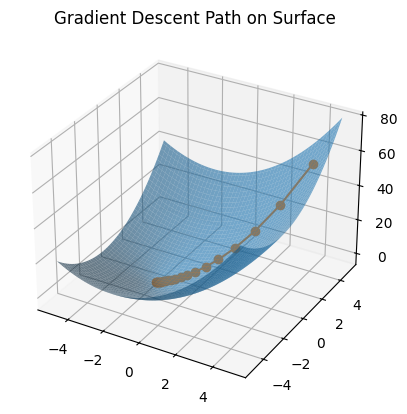

In [6]:
def grad_2d(x, y):
    df_dx = 2*x + 4
    df_dy = 2*y + 2
    return df_dx, df_dy

def gradient_descent_2d(x0, y0, lr=0.1, steps=20):
    x_vals = [x0]
    y_vals = [y0]

    x, y = x0, y0

    for _ in range(steps):
        dx, dy = grad_2d(x, y)
        x -= lr * dx
        y -= lr * dy

        x_vals.append(x)
        y_vals.append(y)

    return x_vals, y_vals

x_path, y_path = gradient_descent_2d(4, 4)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(X, Y, Z, alpha=0.6)

z_path = f(np.array(x_path), np.array(y_path))
ax.plot(x_path, y_path, z_path, marker='o')

ax.set_title("Gradient Descent Path on Surface")
plt.show()

## **Interactive 3D Loss + Animation**

In [11]:
!pip install plotly

import plotly.graph_objects as go
import plotly.io as pio
import numpy as np

# ✅ Force Colab renderer
pio.renderers.default = "colab"

# Dataset
np.random.seed(42)
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)
X_b = np.c_[np.ones((len(X),1)), X]

# Loss
def compute_loss(theta):
    m = len(y)
    return (1/(2*m)) * np.sum((X_b.dot(theta) - y)**2)

# Gradient
def gradient(theta):
    m = len(y)
    return (1/m) * X_b.T.dot(X_b.dot(theta) - y)

# Gradient Descent Path
def gradient_descent(theta_init, lr=0.1, steps=30):
    theta = theta_init.copy()
    path = [theta.copy()]
    for _ in range(steps):
        theta = theta - lr * gradient(theta)
        path.append(theta.copy())
    return path

# Grid for surface
theta0_vals = np.linspace(0, 8, 30)
theta1_vals = np.linspace(0, 5, 30)

T0, T1 = np.meshgrid(theta0_vals, theta1_vals)
Z = np.zeros_like(T0)

for i in range(T0.shape[0]):
    for j in range(T0.shape[1]):
        theta = np.array([[T0[i,j]], [T1[i,j]]])
        Z[i,j] = compute_loss(theta)

# 🎲 Random start
theta_init = np.random.rand(2,1) * [8,5]

# Compute path
path = gradient_descent(theta_init, lr=0.1, steps=25)

theta0_path = [p[0,0] for p in path]
theta1_path = [p[1,0] for p in path]
loss_path = [compute_loss(p) for p in path]

# 🎬 Animation frames
frames = []
for k in range(len(path)):
    frames.append(go.Frame(
        data=[
            go.Scatter3d(
                x=theta0_path[:k+1],
                y=theta1_path[:k+1],
                z=loss_path[:k+1],
                mode='lines+markers'
            )
        ]
    ))

# Plot
fig = go.Figure(
    data=[
        go.Surface(x=T0, y=T1, z=Z),
        go.Scatter3d(
            x=[theta0_path[0]],
            y=[theta1_path[0]],
            z=[loss_path[0]],
            mode='markers',
            name="Start"
        )
    ],
    frames=frames
)

# Controls
fig.update_layout(
    title="3D Loss Surface + Gradient Descent (Colab Working)",
    scene=dict(
        xaxis_title='theta0',
        yaxis_title='theta1',
        zaxis_title='Loss'
    ),
    updatemenus=[{
        "type": "buttons",
        "buttons": [
            {
                "label": "▶ Play",
                "method": "animate",
                "args": [None, {"frame": {"duration": 200, "redraw": True}}]
            }
        ]
    }]
)

fig.show()




## **Interactive Loss Value Interative Solution**

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

def f(x):
    return x**2 + 4*x + 5

def grad(x):
    return 2*x + 4

def gradient_descent(x0, lr=0.1, steps=20):
    x_vals = [x0]
    x = x0

    for _ in range(steps):
        x = x - lr * grad(x)
        x_vals.append(x)

    return x_vals

x_vals = gradient_descent(x0=8)

x = np.linspace(-10, 10, 400)
y = f(x)

fig, ax = plt.subplots()
ax.plot(x, y)

point, = ax.plot([], [], 'ro')

def update(frame):
    x_current = x_vals[frame]
    y_current = f(x_current)
    point.set_data([x_current], [y_current])
    return point,

ani = FuncAnimation(fig, update, frames=len(x_vals), interval=500)

plt.close()  # ❗ Prevent duplicate static plot

# ✅ THIS LINE IS THE KEY FIX
HTML(ani.to_jshtml())

## **Interactive Loss Function**

In this interactive module, we explore how mathematical optimizers navigate a loss landscape. We will observe the impact of Learning Rate, Momentum, and Gradient Clipping on convergence stability.1. The Gradient Descent Update RuleThe core of nearly all ML training is Stochastic Gradient Descent (SGD). The parameter $w$ is updated by moving in the opposite direction of the gradient:$$w_{t+1} = w_t - \eta \nabla L(w_t)$$Where:$\eta$ is the Learning Rate (step size).$\nabla L(w_t)$ is the Gradient (the slope at the current point).2. SGD with MomentumStandard SGD can struggle with local minima or "oscillate" in narrow valleys. Momentum adds a velocity term $v$ to help the optimizer maintain its direction:$$v_{t+1} = \gamma v_t + \eta \nabla L(w_t)$$$$w_{t+1} = w_t - v_{t+1}$$$\gamma$ is the Momentum Coefficient (usually 0.9), representing "friction."3. Gradient ClippingOn steep surfaces, the gradient $\nabla L(w)$ can become massive, leading to Numerical Explosion. Clipping limits the maximum change in weight to a fixed threshold:$$\text{if } |v| > \text{threshold, then } v = \text{sign}(v) \cdot \text{threshold}$$

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output

# --- 1. LOSS FUNCTIONS & GRADIENTS ---
functions = {
    "Quadratic (Convex)": {
        "f": lambda x: x**2,
        "df": lambda x: 2*x,
        "range": (-3, 3)
    },
    "Multi-Modal (Non-Convex)": {
        "f": lambda x: x**4 - 3*x**3 + 2,
        "df": lambda x: 4*x**3 - 9*x**2,
        "range": (-1, 3)
    },
    "Rosenbrock (Tamed)": {
        "f": lambda x: (1 - x)**2 + 5 * (x**2)**2,
        "df": lambda x: -2*(1 - x) + 20 * x**3,
        "range": (-2, 2)
    }
}

# --- 2. THE DASHBOARD UI COMPONENTS ---
style = {'description_width': 'initial'}

select_fn = widgets.Dropdown(options=functions.keys(), description="Function:", style=style)
start_x = widgets.FloatSlider(value=1.8, min=-3, max=3, step=0.1, description="Start Point:", style=style)
lr_slider = widgets.FloatSlider(value=0.02, min=0.001, max=0.5, step=0.005, description="Learning Rate:", style=style)
chk_momentum = widgets.Checkbox(value=False, description="Enable Momentum (0.9)", style=style)
chk_clipping = widgets.Checkbox(value=False, description="Enable Gradient Clipping", style=style)
btn_run = widgets.Button(description="🚀 Run Animation", button_style='primary')

plot_output = widgets.Output()

# --- 3. UPDATED ANIMATION LOGIC ---
def run_optimization(b=None):
    with plot_output:
        clear_output(wait=True)

        fn_name = select_fn.value
        f = functions[fn_name]["f"]
        df = functions[fn_name]["df"]
        x_range = functions[fn_name]["range"]

        eta = lr_slider.value
        curr_x = start_x.value

        # Path and Momentum variables
        path_x = [curr_x]
        v = 0 # velocity
        gamma = 0.9 if chk_momentum.value else 0
        clip_threshold = 0.5 # Max step size

        for _ in range(50):
            grad = df(curr_x)

            # Apply Momentum update rule: v = gamma*v + eta*grad
            v = gamma * v + eta * grad

            # Apply Gradient Clipping if enabled
            if chk_clipping.value:
                v = np.clip(v, -clip_threshold, clip_threshold)

            curr_x = curr_x - v
            path_x.append(curr_x)

        # Animation Setup
        fig, ax = plt.subplots(figsize=(7, 5), dpi=100)
        x_vals = np.linspace(x_range[0], x_range[1], 500)
        ax.plot(x_vals, f(x_vals), 'k-', alpha=0.3)
        ax.set_title(f"Optimizing: {fn_name}")
        ax.set_xlabel("Parameter (w)")
        ax.set_ylabel("Loss L(w)")

        point, = ax.plot([], [], 'ro', ms=8)
        line, = ax.plot([], [], 'r--', alpha=0.5)

        def init():
            point.set_data([], [])
            line.set_data([], [])
            return point, line

        def update(frame):
            cx = path_x[frame]
            cy = f(cx)
            point.set_data([cx], [cy])
            line.set_data(path_x[:frame], [f(x) for x in path_x[:frame]])
            return point, line

        ani = FuncAnimation(fig, update, frames=len(path_x), init_func=init, blit=True, interval=80)
        plt.close()
        display(HTML(ani.to_jshtml()))

btn_run.on_click(run_optimization)

# --- 4. LAYOUT ---
controls = widgets.VBox([
    widgets.HTML("<b>Advanced Optimizer Controls</b>"),
    select_fn, start_x, lr_slider,
    chk_momentum, chk_clipping,
    btn_run
], layout=widgets.Layout(width='320px', padding='10px', border='1px solid #ccc', margin='0 20px 0 0'))

display(widgets.HBox([controls, plot_output]))
run_optimization() # Initial run